In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import re
import numpy as np

year= 2024
df = pd.read_csv(f"final_data/season_players_dataset_{year}/season_players_dataset_with_context_{year}.csv")

y = df['team_home_wins']
X = df.drop(['team_home_wins', 'game_id'], axis=1)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)

# Players dataset, without dimentional reduction

In [4]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)


for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. th_player1_plus_minus: 0.32050188
2. ta_player1_plus_minus: 0.23882954
3. th_player2_plus_minus: 0.03304539
4. ta_player6_plus_minus: 0.03259291
5. th_player3_plus_minus: 0.02586565
6. ta_player2_plus_minus: 0.02399424
7. th_player4_plus_minus: 0.01920284
8. th_player7_plus_minus: 0.01389068
9. ta_player7_plus_minus: 0.01229232
10. ta_player5_plus_minus: 0.01214378
11. th_player6_plus_minus: 0.01199703
12. th_player5_plus_minus: 0.01127743
13. ta_player4_plus_minus: 0.00787734
14. ta_player3_plus_minus: 0.00711372
15. ta_player4_def_rtg: 0.00216969
16. ta_player5_def_rtg: 0.00209603
17. ta_player2_def_rtg: 0.00190666
18. th_player7_def_rtg: 0.00158956
19. ta_player1_def_rtg: 0.00155566
20. th_player3_def_rtg: 0.00148625
21. th_player1_def_rtg: 0.00146522
22. th_player5_def_rtg: 0.00135184
23. ta_player6_def_rtg: 0.00125615
24. ta_player7_def_rtg: 0.00122367
25. ta_player3_def_rtg: 0.00114725
26. th_player2_def_rtg: 0.00114374
27. ta_context2_player3_usg_pct: 0.00108290
28. th_player

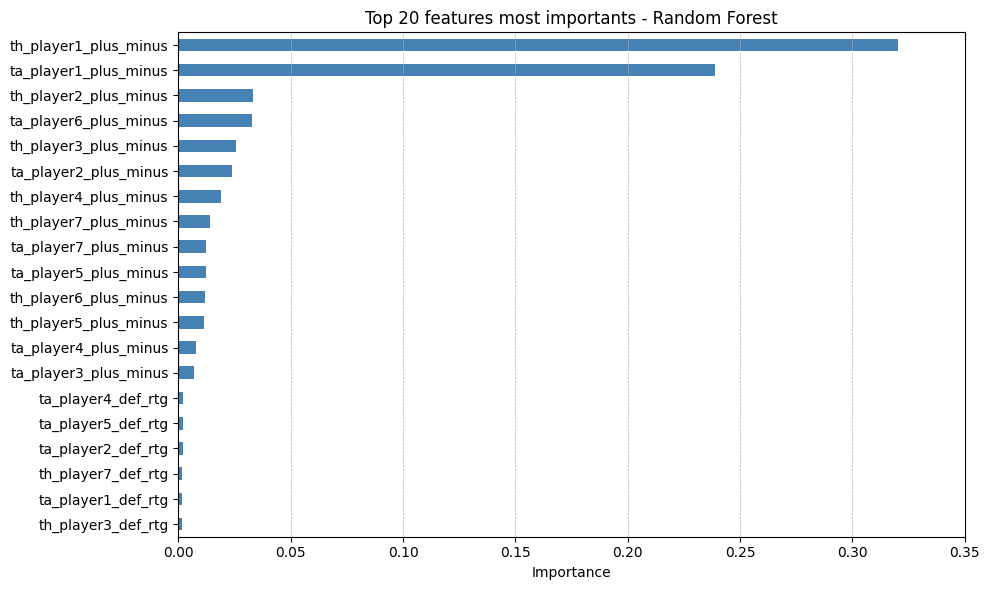

In [ ]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [14]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. th_player1_plus_minus: 0.17439391
2. th_player6_historic_GS: 0.05021884
3. ta_player1_plus_minus: 0.04601653
4. th_context4_player7_stl: 0.04214246
5. ta_context1_player6_orb_pct: 0.03250846
6. th_player5_trb: 0.02661836
7. ta_player6_plus_minus: 0.02418860
8. th_player2_plus_minus: 0.02258370
9. th_player4_pts: 0.02123377
10. ta_context1_player5_fg3a: 0.01956854
11. th_player4_trb_pct: 0.01891481
12. th_player6_plus_minus: 0.01849278
13. ta_player2_orb: 0.01847021
14. ta_context1_player6_bpm: 0.01820756
15. th_player1_historic_FG%: 0.01657980
16. ta_player6_fg_pct: 0.01557259
17. ta_player7_drb: 0.01552717
18. th_player4_plus_minus: 0.01463783
19. ta_context3_player6_pf: 0.01424778
20. th_player7_plus_minus: 0.01393872
21. ta_player4_plus_minus: 0.01262520
22. ta_player6_historic_G: 0.01262394
23. th_player5_fga: 0.01240921
24. th_player5_plus_minus: 0.01077932
25. th_context1_player5_drb_pct: 0.01050792
26. ta_player7_plus_minus: 0.00979640
27. th_player3_plus_minus: 0.00916787
28

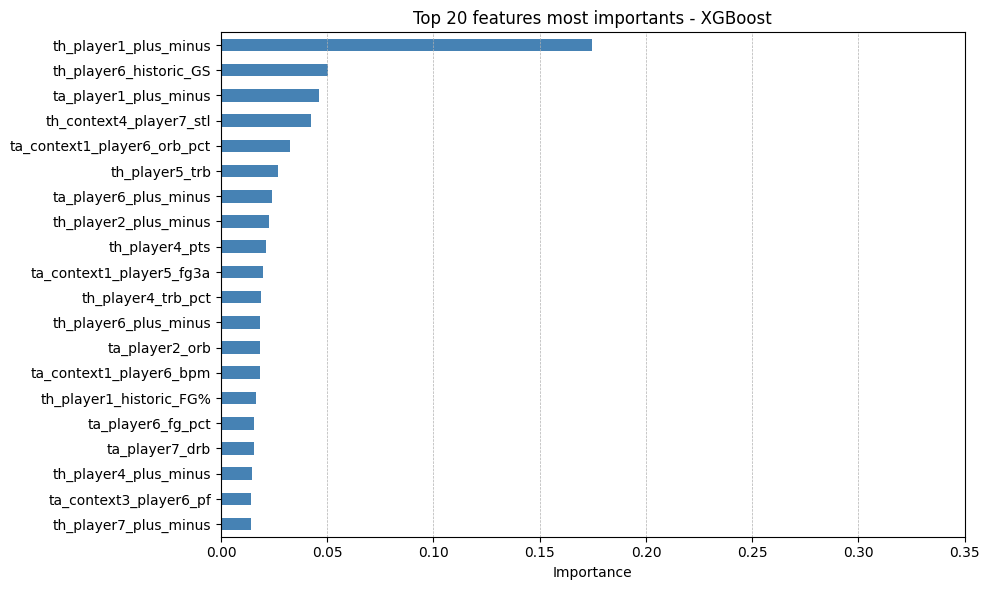

In [17]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

# Teams dataset, without dimentional reduction

In [18]:
year= 2024
df = pd.read_csv(f"final_data/season_teams_dataset_{year}/season_teams_dataset_with_context_{year}.csv")

y = df['team_home_wins']
X = df.drop(['team_home_wins', 'game_id'], axis=1)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)

In [19]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. team_away_off_rtg: 0.19231305
2. team_home_def_rtg: 0.18538805
3. team_home_off_rtg: 0.18010945
4. team_away_def_rtg: 0.16967719
5. team_home_ts_pct: 0.05936931
6. team_home_pts: 0.03850339
7. team_away_ts_pct: 0.03293813
8. team_away_pts: 0.02023738
9. team_home_fg_pct: 0.00583545
10. team_away_pf: 0.00403421
11. team_home_efg_pct: 0.00364326
12. team_home_fta: 0.00292596
13. team_home_fg: 0.00273790
14. team_home_fta_per_fga_pct: 0.00259408
15. team_away_efg_pct: 0.00228430
16. team_away_fg_pct: 0.00228405
17. team_away_blk_pct: 0.00139617
18. team_away_context2_pf: 0.00109777
19. team_home_context4_orb: 0.00102320
20. team_home_context1_tov_pct: 0.00088901
21. team_home_context4_orb_pct: 0.00077629
22. team_home_ft: 0.00072943
23. team_away_context4_stl_pct: 0.00071392
24. team_away_context1_trb_pct: 0.00070637
25. team_away_context1_drb: 0.00070616
26. team_away_ast_pct: 0.00070431
27. team_away_context4_drb_pct: 0.00067458
28. team_away_context2_fg3_pct: 0.00064874
29. team_awa

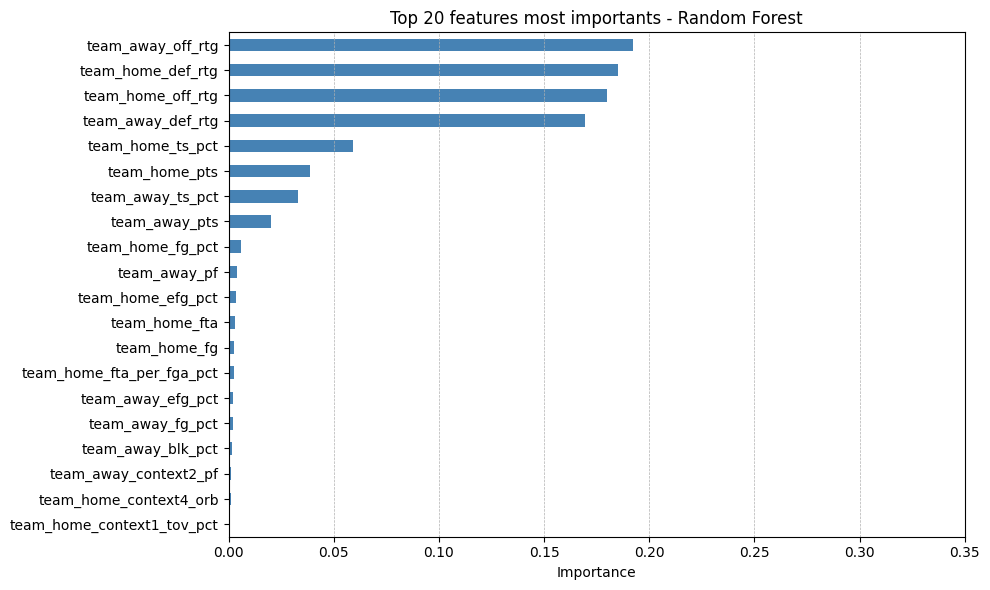

In [21]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [22]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. team_away_off_rtg: 0.36263698
2. team_away_def_rtg: 0.30629444
3. team_home_pts: 0.08636203
4. team_away_context3_orb: 0.04673948
5. team_home_context4_orb: 0.03473650
6. team_home_context4_blk: 0.02749248
7. team_home_fg_pct: 0.02200434
8. team_home_2020_historic_def_rtg: 0.01716167
9. team_away_ast: 0.00961050
10. team_home_context3_fg_pct: 0.00934284
11. team_away_fg3a: 0.00890822
12. team_away_fg3_pct: 0.00817971
13. team_away_fg_pct: 0.00815175
14. team_home_2020_historic_srs: 0.00794858
15. team_home_ts_pct: 0.00483211
16. team_home_fta: 0.00424602
17. team_home_context1_fga: 0.00328887
18. team_home_context2_drb_pct: 0.00325589
19. team_away_2020_historic_stl_per_g: 0.00239843
20. team_home_context1_tov: 0.00228870
21. team_away_context1_drb: 0.00222986
22. team_home_fg: 0.00142198
23. team_away_context2_ast: 0.00134252
24. team_home_context2_fg3: 0.00131189
25. team_away_2020_historic_trb_per_g: 0.00123522
26. team_home_context2_fg3_pct: 0.00113190
27. team_away_context1_trb

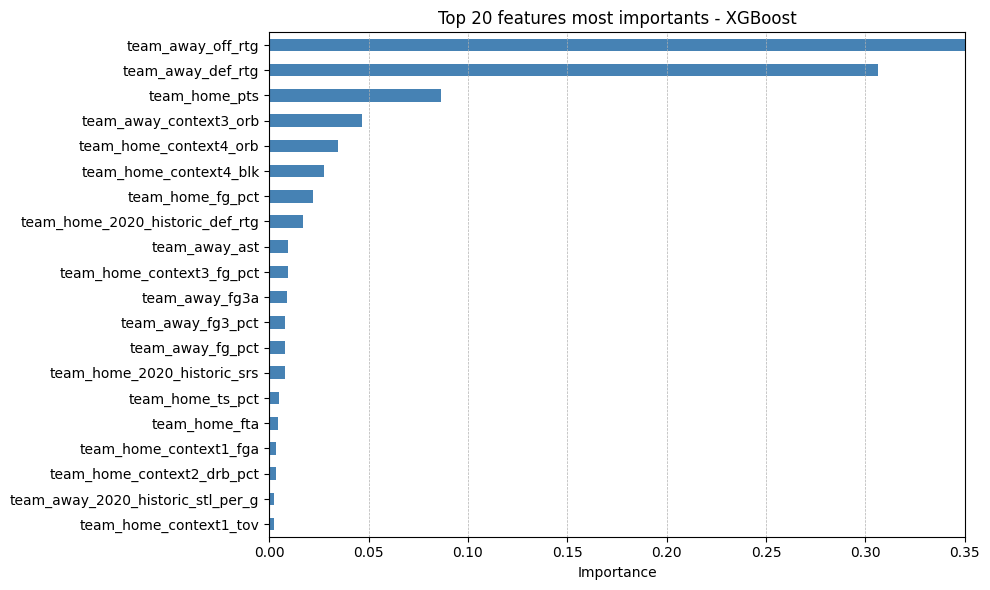

In [24]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

# Players dataset, with dimentional reduction

### All components

In [26]:
year= 2024
df = pd.read_csv(f"final_data/season_players_dataset_{year}_reduced/season_players_dataset_with_context_{year}.csv")

y = df['team_home_wins']
X = df.drop(['team_home_wins', 'game_id'], axis=1)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)

In [27]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. th_player1_PCA6_1: 0.33801454
2. ta_player1_PCA6_1: 0.12384257
3. th_player3_PCA6_1: 0.05292706
4. th_player2_PCA6_1: 0.03413319
5. ta_player1_PCA6_3: 0.03146885
6. ta_player2_PCA6_1: 0.02266371
7. ta_player2_PCA6_3: 0.02059817
8. th_player1_PCA6_3: 0.01488101
9. th_player2_PCA6_3: 0.01197848
10. th_player5_PCA6_3: 0.01180216
11. ta_player6_PCA6_3: 0.01102075
12. th_player6_PCA6_1: 0.01015372
13. th_player5_PCA6_1: 0.01009633
14. ta_player5_PCA6_1: 0.01005435
15. th_player4_PCA6_1: 0.00998676
16. th_player7_PCA6_1: 0.00927421
17. ta_player7_PCA6_1: 0.00896359
18. th_player4_PCA6_3: 0.00895190
19. ta_player6_PCA6_1: 0.00874597
20. ta_player3_PCA6_1: 0.00871038
21. th_player3_PCA6_3: 0.00769098
22. ta_player5_PCA6_3: 0.00720331
23. ta_player3_PCA6_3: 0.00714900
24. ta_player4_PCA6_1: 0.00510225
25. ta_player4_PCA6_3: 0.00383313
26. ta_player7_PCA6_3: 0.00377783
27. th_player6_PCA6_3: 0.00342047
28. th_player7_PCA6_3: 0.00191579
29. ta_context4_player3_PCA2_1: 0.00124039
30. ta_context

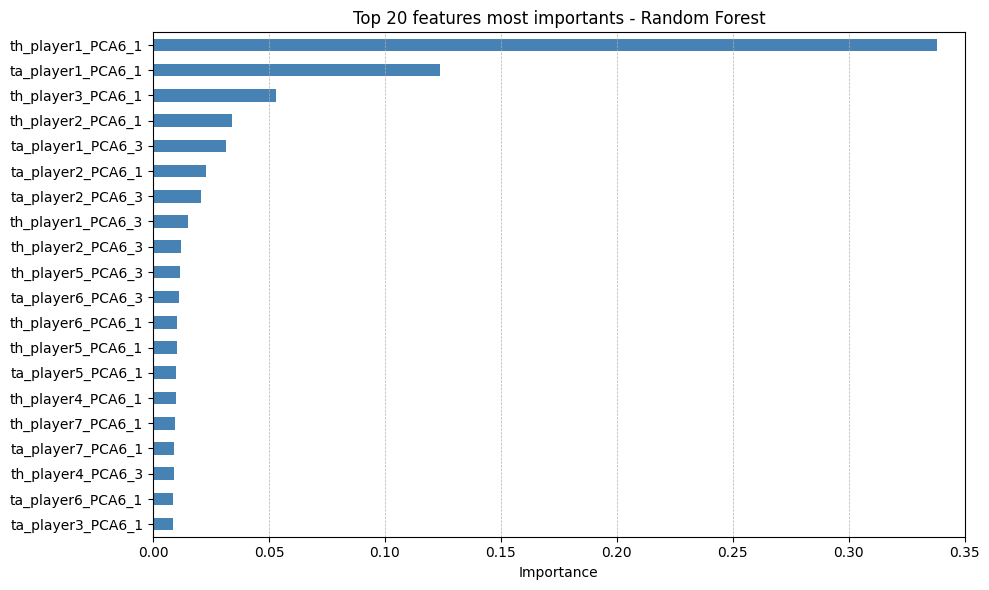

In [28]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [29]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. th_player1_PCA6_1: 0.18227437
2. th_player3_PCA6_1: 0.05810643
3. ta_player3_historic_PCA2_1: 0.04342907
4. th_player7_historic_PCA3_1: 0.03265859
5. th_player2_PCA6_1: 0.03150954
6. th_player7_PCA6_1: 0.02793315
7. ta_player2_PCA6_3: 0.02385946
8. ta_context4_player2_PCA5_1: 0.01980712
9. th_context1_player7_PCA6_1: 0.01938771
10. ta_player1_PCA6_1: 0.01849063
11. th_player6_PCA6_1: 0.01833446
12. th_player4_PCA6_3: 0.01629851
13. ta_context2_player1_PCA2_2: 0.01465420
14. th_player5_PCA6_1: 0.01447231
15. ta_context1_player4_PCA1_1: 0.01366383
16. ta_context4_player1_PCA2_1: 0.01353746
17. th_player3_historic_PCA3_2: 0.01327657
18. ta_context3_player5_PCA4_2: 0.01327119
19. ta_player1_PCA6_3: 0.01270183
20. ta_context4_player1_PCA3_2: 0.01181595
21. ta_player2_PCA2_3: 0.01178732
22. th_context3_player1_PCA6_3: 0.01109157
23. th_player5_PCA6_3: 0.01067721
24. ta_player7_PCA6_1: 0.01061554
25. th_player4_PCA6_1: 0.01054365
26. ta_player3_PCA6_3: 0.01048582
27. ta_context3_player1_PC

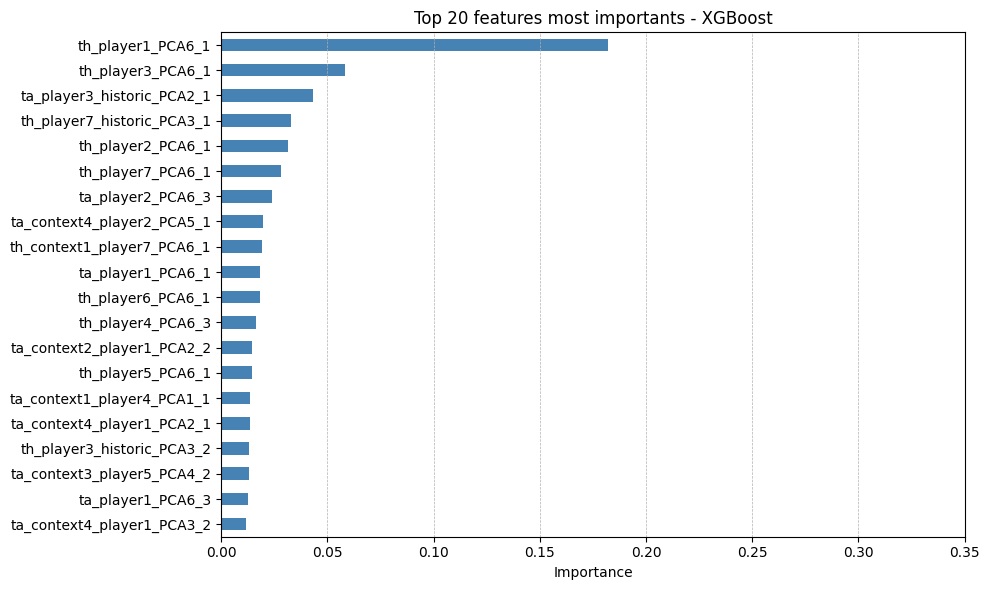

In [30]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

### Three firsts components

In [31]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 3]
df_first_second_third_components = df[filter_cols]
y = df_first_second_third_components['team_home_wins']
X = df_first_second_third_components.drop(['team_home_wins', 'game_id'], axis=1)

In [32]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. th_player1_PCA6_1: 0.33801454
2. ta_player1_PCA6_1: 0.12384257
3. th_player3_PCA6_1: 0.05292706
4. th_player2_PCA6_1: 0.03413319
5. ta_player1_PCA6_3: 0.03146885
6. ta_player2_PCA6_1: 0.02266371
7. ta_player2_PCA6_3: 0.02059817
8. th_player1_PCA6_3: 0.01488101
9. th_player2_PCA6_3: 0.01197848
10. th_player5_PCA6_3: 0.01180216
11. ta_player6_PCA6_3: 0.01102075
12. th_player6_PCA6_1: 0.01015372
13. th_player5_PCA6_1: 0.01009633
14. ta_player5_PCA6_1: 0.01005435
15. th_player4_PCA6_1: 0.00998676
16. th_player7_PCA6_1: 0.00927421
17. ta_player7_PCA6_1: 0.00896359
18. th_player4_PCA6_3: 0.00895190
19. ta_player6_PCA6_1: 0.00874597
20. ta_player3_PCA6_1: 0.00871038
21. th_player3_PCA6_3: 0.00769098
22. ta_player5_PCA6_3: 0.00720331
23. ta_player3_PCA6_3: 0.00714900
24. ta_player4_PCA6_1: 0.00510225
25. ta_player4_PCA6_3: 0.00383313
26. ta_player7_PCA6_3: 0.00377783
27. th_player6_PCA6_3: 0.00342047
28. th_player7_PCA6_3: 0.00191579
29. ta_context4_player3_PCA2_1: 0.00124039
30. ta_context

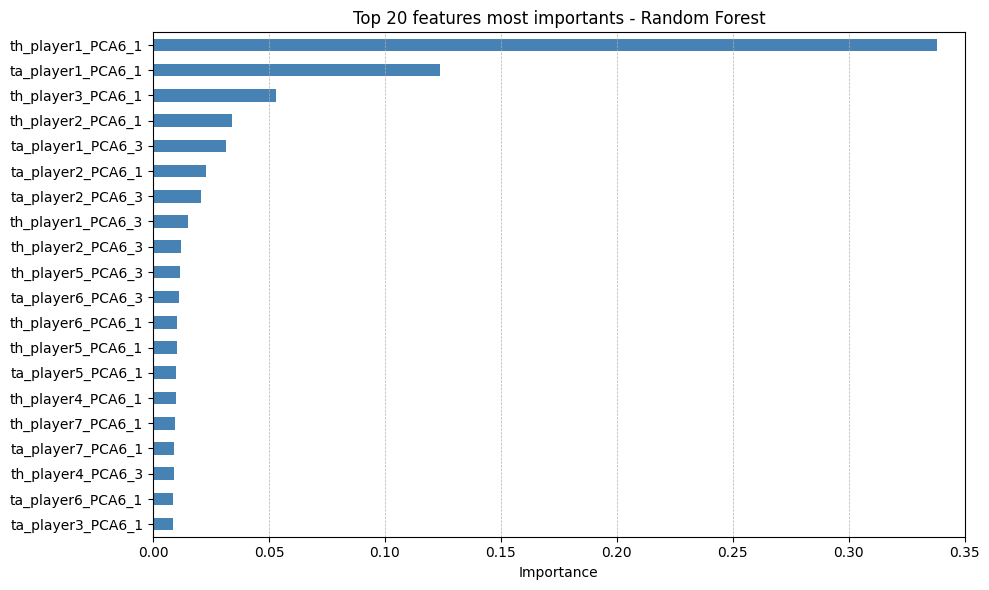

In [33]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [34]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. th_player1_PCA6_1: 0.18227437
2. th_player3_PCA6_1: 0.05810643
3. ta_player3_historic_PCA2_1: 0.04342907
4. th_player7_historic_PCA3_1: 0.03265859
5. th_player2_PCA6_1: 0.03150954
6. th_player7_PCA6_1: 0.02793315
7. ta_player2_PCA6_3: 0.02385946
8. ta_context4_player2_PCA5_1: 0.01980712
9. th_context1_player7_PCA6_1: 0.01938771
10. ta_player1_PCA6_1: 0.01849063
11. th_player6_PCA6_1: 0.01833446
12. th_player4_PCA6_3: 0.01629851
13. ta_context2_player1_PCA2_2: 0.01465420
14. th_player5_PCA6_1: 0.01447231
15. ta_context1_player4_PCA1_1: 0.01366383
16. ta_context4_player1_PCA2_1: 0.01353746
17. th_player3_historic_PCA3_2: 0.01327657
18. ta_context3_player5_PCA4_2: 0.01327119
19. ta_player1_PCA6_3: 0.01270183
20. ta_context4_player1_PCA3_2: 0.01181595
21. ta_player2_PCA2_3: 0.01178732
22. th_context3_player1_PCA6_3: 0.01109157
23. th_player5_PCA6_3: 0.01067721
24. ta_player7_PCA6_1: 0.01061554
25. th_player4_PCA6_1: 0.01054365
26. ta_player3_PCA6_3: 0.01048582
27. ta_context3_player1_PC

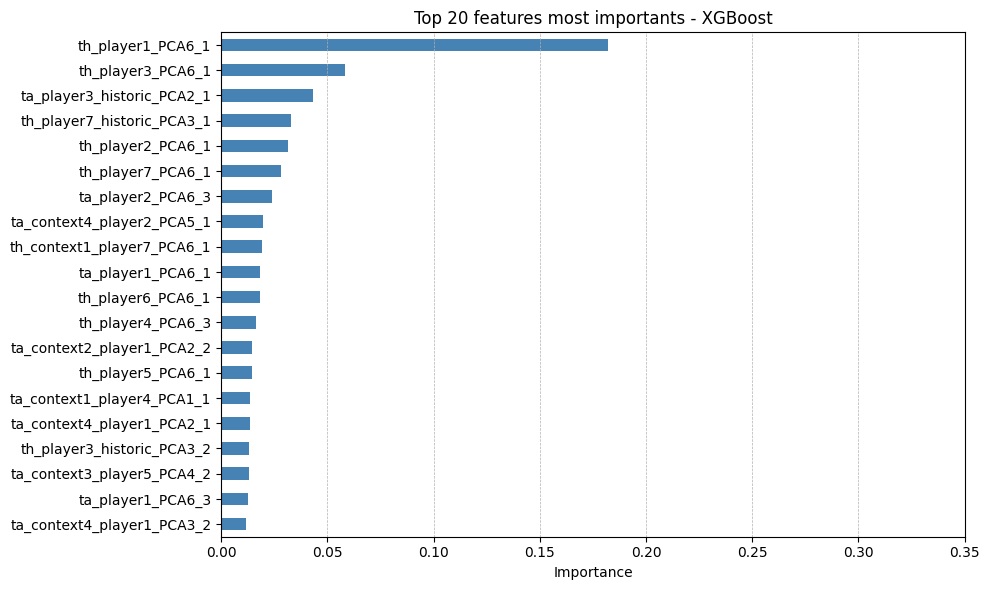

In [35]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

### Two firsts components

In [36]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 2]
df_first_second_components = df[filter_cols]
y = df_first_second_components['team_home_wins']
X = df_first_second_components.drop(['team_home_wins', 'game_id'], axis=1)

In [37]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. th_player1_PCA6_1: 0.35237911
2. ta_player1_PCA6_1: 0.13960760
3. th_player3_PCA6_1: 0.06280723
4. th_player2_PCA6_1: 0.04842604
5. ta_player2_PCA6_1: 0.03720216
6. th_player4_PCA6_1: 0.01853592
7. th_player5_PCA6_1: 0.01601331
8. th_player6_PCA6_1: 0.01566998
9. ta_player6_PCA6_1: 0.01440702
10. ta_player3_PCA6_1: 0.01431152
11. ta_player5_PCA6_1: 0.01369637
12. th_player7_PCA6_1: 0.01338469
13. ta_player7_PCA6_1: 0.01254769
14. ta_player4_PCA6_1: 0.00890816
15. ta_context2_player3_PCA6_2: 0.00134498
16. ta_player1_PCA5_1: 0.00124846
17. th_player1_PCA4_2: 0.00124753
18. ta_player4_PCA4_1: 0.00124682
19. th_player2_historic_PCA2_1: 0.00117240
20. th_player4_PCA4_1: 0.00114919
21. th_player7_historic_PCA5_1: 0.00113037
22. th_player2_historic_PCA3_2: 0.00112013
23. ta_context4_player3_PCA2_1: 0.00100323
24. th_context3_player2_PCA3_2: 0.00095069
25. ta_player4_PCA3_1: 0.00090129
26. th_context1_player5_PCA6_1: 0.00088769
27. th_context2_player3_PCA6_1: 0.00088578
28. ta_context4_pla

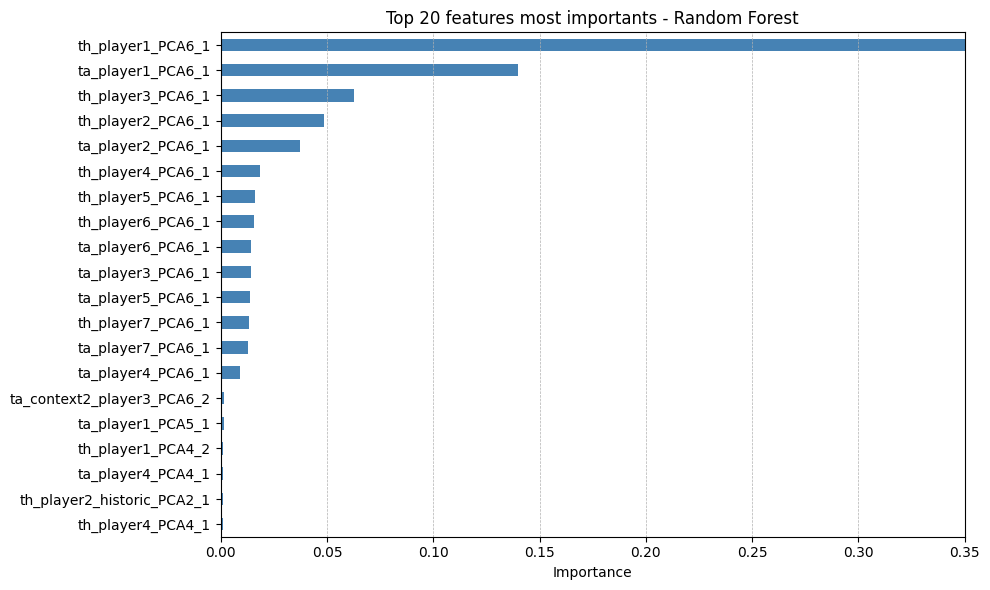

In [38]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [39]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. th_player1_PCA6_1: 0.17722020
2. th_player3_PCA6_1: 0.05430406
3. ta_player1_PCA6_1: 0.05365263
4. th_context2_player1_PCA3_2: 0.02262624
5. th_player2_PCA6_1: 0.02077562
6. th_context3_player5_PCA3_2: 0.01972101
7. ta_player5_PCA6_2: 0.01833933
8. th_player6_PCA6_1: 0.01822473
9. ta_context4_player5_PCA2_1: 0.01746220
10. th_player2_PCA2_1: 0.01727941
11. ta_player2_historic_PCA1_1: 0.01720935
12. ta_context4_player7_PCA3_2: 0.01710923
13. th_player7_PCA6_1: 0.01661045
14. th_player4_PCA6_1: 0.01567237
15. ta_player7_PCA6_1: 0.01563599
16. th_player5_PCA6_1: 0.01556945
17. th_context2_player5_PCA6_2: 0.01550553
18. ta_player5_PCA6_1: 0.01468578
19. th_player3_PCA4_1: 0.01442495
20. ta_player2_PCA6_1: 0.01418925
21. th_player5_PCA6_2: 0.01339615
22. th_player6_PCA2_1: 0.01242408
23. ta_player4_PCA6_1: 0.01231716
24. th_context4_player4_PCA5_1: 0.01128974
25. ta_player3_PCA6_1: 0.01091113
26. ta_player7_historic_PCA2_1: 0.01084044
27. th_context1_player2_PCA4_2: 0.01019176
28. th_con

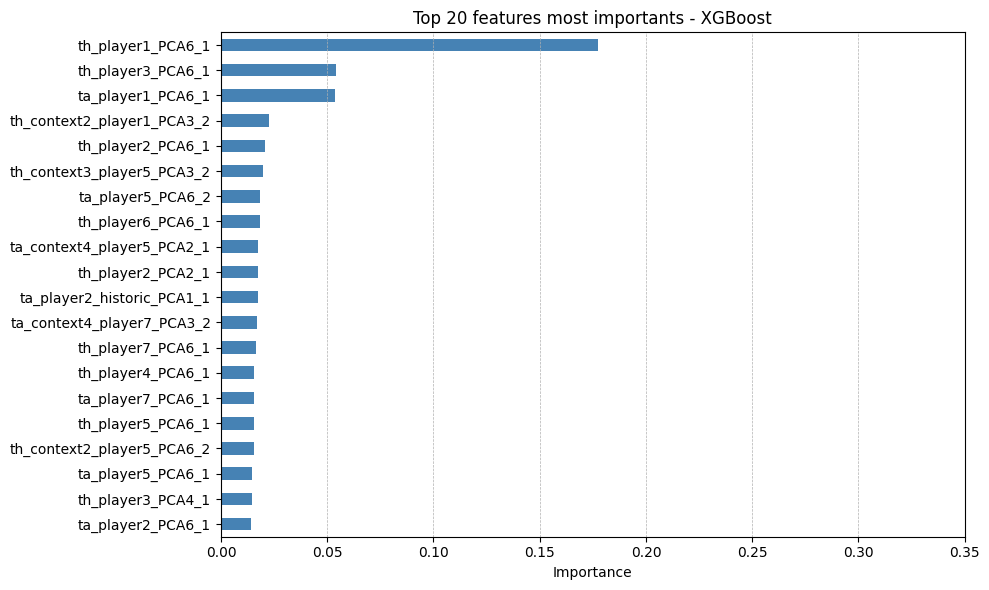

In [40]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

### First component

In [41]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 1]
df_first_components = df[filter_cols]
y = df_first_components['team_home_wins']
X = df_first_components.drop(['team_home_wins', 'game_id'], axis=1)

In [42]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. th_player1_PCA6_1: 0.35384598
2. ta_player1_PCA6_1: 0.14041637
3. th_player3_PCA6_1: 0.06383896
4. th_player2_PCA6_1: 0.04972197
5. ta_player2_PCA6_1: 0.03837000
6. th_player4_PCA6_1: 0.01978160
7. th_player6_PCA6_1: 0.01749596
8. th_player5_PCA6_1: 0.01742786
9. ta_player6_PCA6_1: 0.01618396
10. ta_player5_PCA6_1: 0.01547230
11. ta_player3_PCA6_1: 0.01537809
12. ta_player7_PCA6_1: 0.01464475
13. th_player7_PCA6_1: 0.01462498
14. ta_player4_PCA6_1: 0.01001574
15. ta_player4_PCA4_1: 0.00189505
16. ta_context4_player3_PCA2_1: 0.00172261
17. ta_player1_PCA5_1: 0.00163636
18. th_player2_historic_PCA2_1: 0.00147796
19. th_player7_historic_PCA5_1: 0.00147360
20. th_player4_PCA4_1: 0.00134547
21. th_context2_player3_PCA6_1: 0.00130374
22. th_context1_player5_PCA6_1: 0.00129346
23. ta_player4_PCA3_1: 0.00126449
24. ta_player2_PCA5_1: 0.00124139
25. th_player2_PCA2_1: 0.00116894
26. th_context2_player3_PCA5_1: 0.00112646
27. ta_context3_player4_PCA1_1: 0.00111963
28. ta_context4_player3_PCA3

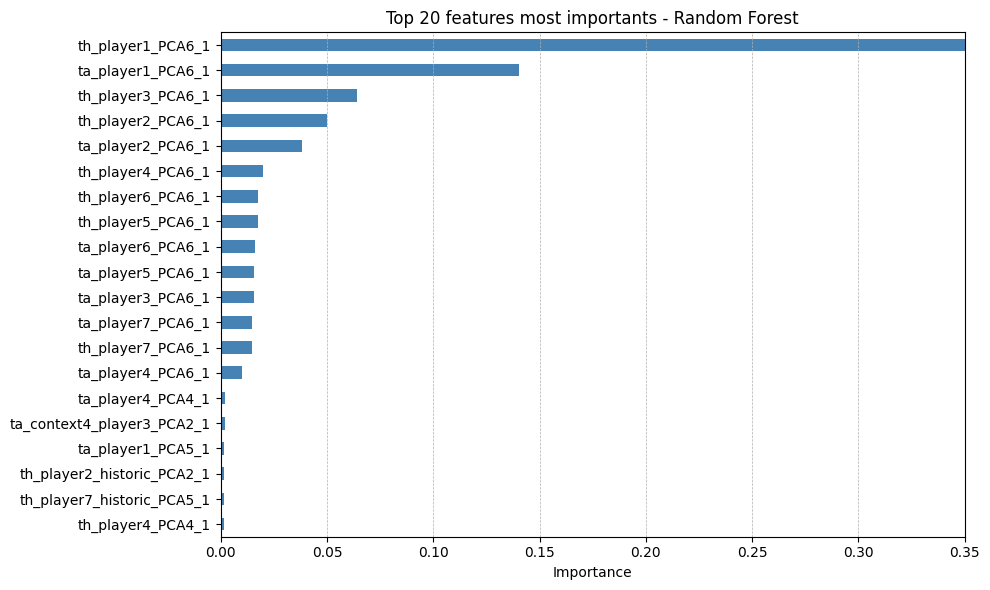

In [43]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [44]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. th_player1_PCA6_1: 0.22302803
2. th_player3_PCA6_1: 0.08005910
3. ta_context4_player5_PCA2_1: 0.04790450
4. ta_player1_PCA6_1: 0.04104846
5. th_context3_player5_PCA6_1: 0.02768710
6. th_player6_PCA6_1: 0.02480558
7. th_player5_PCA6_1: 0.02222624
8. th_player3_historic_PCA3_1: 0.02177234
9. th_player7_PCA6_1: 0.02018853
10. th_player4_PCA6_1: 0.01864701
11. th_player2_PCA6_1: 0.01803121
12. ta_player6_PCA6_1: 0.01601609
13. th_context1_player5_PCA6_1: 0.01534991
14. ta_player2_PCA6_1: 0.01468766
15. th_context2_player3_PCA2_1: 0.01405821
16. ta_player7_PCA6_1: 0.01405432
17. ta_player4_PCA6_1: 0.01369392
18. ta_context4_player3_PCA5_1: 0.01307185
19. ta_player5_PCA6_1: 0.01264196
20. ta_context1_player7_PCA4_1: 0.01111668
21. th_context1_player5_PCA5_1: 0.01011691
22. ta_context3_player5_PCA5_1: 0.01005079
23. ta_context1_player5_PCA4_1: 0.01003114
24. ta_context1_player1_PCA1_1: 0.00981098
25. ta_context3_player7_PCA1_1: 0.00961512
26. ta_player6_historic_PCA2_1: 0.00892627
27. ta_p

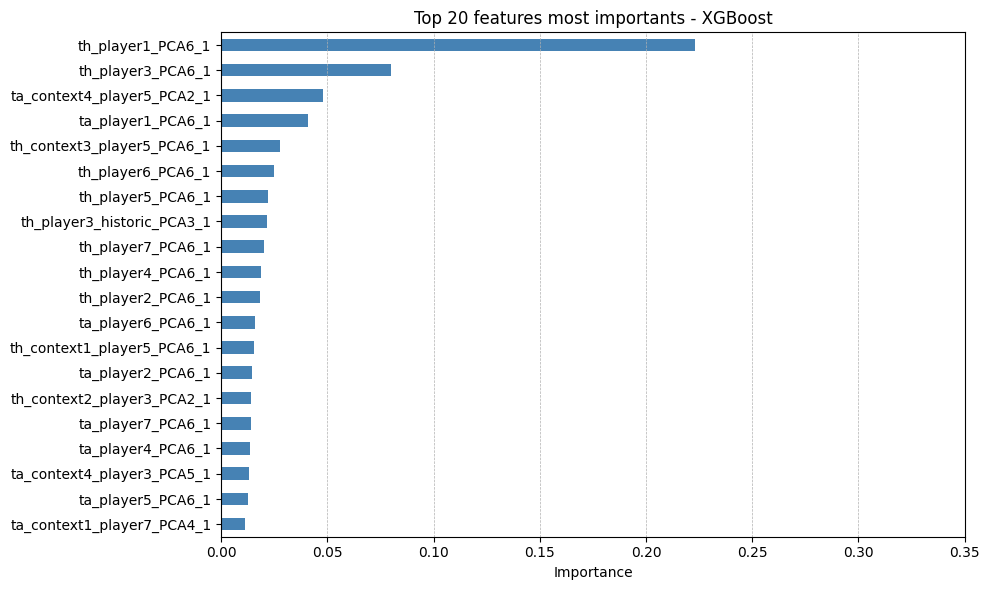

In [45]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

# Teams dataset, with dimentional reduction

### All components

In [46]:
year= 2024
df = pd.read_csv(f"final_data/season_teams_dataset_{year}_reduced/season_teams_dataset_with_context_{year}.csv")

y = df['team_home_wins']
X = df.drop(['team_home_wins', 'game_id'], axis=1)
X = X.select_dtypes(exclude=['object', 'string'])

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)

In [47]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. team_away_PCA4_1: 0.32001117
2. team_home_PCA4_1: 0.31348741
3. team_home_PCA5_1: 0.02721906
4. team_away_PCA2_1: 0.02318972
5. team_away_PCA2_4: 0.01537291
6. team_home_PCA2_1: 0.01236838
7. team_home_PCA3_1: 0.01106933
8. team_away_PCA3_1: 0.01018054
9. team_home_PCA1_1: 0.00978166
10. team_away_PCA1_1: 0.00607853
11. team_away_PCA5_1: 0.00589779
12. team_away_PCA2_3: 0.00362251
13. team_away_context4_PCA1_3: 0.00352543
14. team_away_context1_PCA3_1: 0.00345621
15. team_away_PCA1_2: 0.00339640
16. team_home_PCA1_2: 0.00307587
17. team_away_PCA4_3: 0.00299144
18. team_away_PCA5_2: 0.00298142
19. team_home_context3_PCA2_1: 0.00273441
20. team_away_context2_PCA3_1: 0.00252051
21. team_home_2023_historic_PCA3_1: 0.00250573
22. team_away_context2_PCA1_3: 0.00249476
23. team_away_context1_PCA3_2: 0.00246245
24. team_away_context1_PCA1_3: 0.00246078
25. team_home_PCA2_4: 0.00243617
26. team_home_2024_historic_PCA3_1: 0.00241760
27. team_away_PCA1_3: 0.00239195
28. team_home_2020_historic

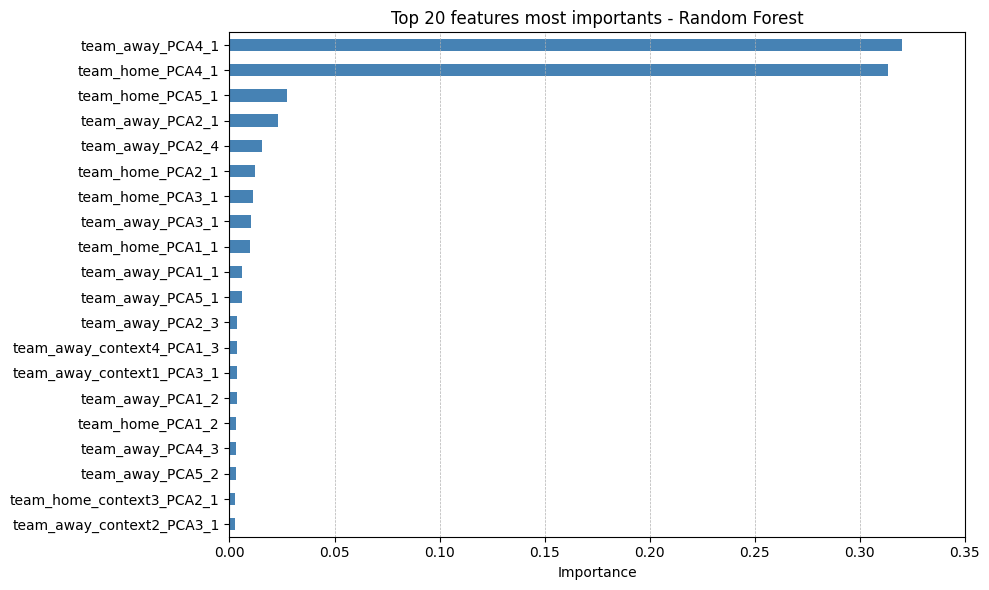

In [48]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [49]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. team_home_PCA4_1: 0.22958328
2. team_away_PCA4_1: 0.20373689
3. team_home_2020_historic_PCA3_1: 0.03534471
4. team_home_PCA5_1: 0.03510542
5. team_home_PCA2_1: 0.02332911
6. team_home_PCA3_1: 0.02222866
7. team_away_PCA2_4: 0.01894586
8. team_home_2020_historic_PCA4_2: 0.01758638
9. team_away_context1_PCA3_2: 0.01673122
10. team_away_context1_PCA3_1: 0.01615567
11. team_home_2020_historic_PCA1_3: 0.01309383
12. team_away_context2_PCA3_1: 0.01307735
13. team_away_PCA2_1: 0.01253968
14. team_home_context2_PCA4_3: 0.01007578
15. team_away_context1_PCA4_2: 0.00995674
16. team_away_context2_PCA5_2: 0.00950029
17. team_home_PCA1_1: 0.00942268
18. team_home_2020_historic_PCA5_1: 0.00913686
19. team_home_context3_PCA2_1: 0.00885320
20. team_away_PCA5_1: 0.00850007
21. team_away_PCA3_1: 0.00787483
22. team_home_context3_PCA4_3: 0.00767399
23. team_away_context1_PCA1_1: 0.00747640
24. team_home_context2_PCA5_2: 0.00745686
25. team_away_context1_PCA2_3: 0.00742491
26. team_home_context2_PCA4_2

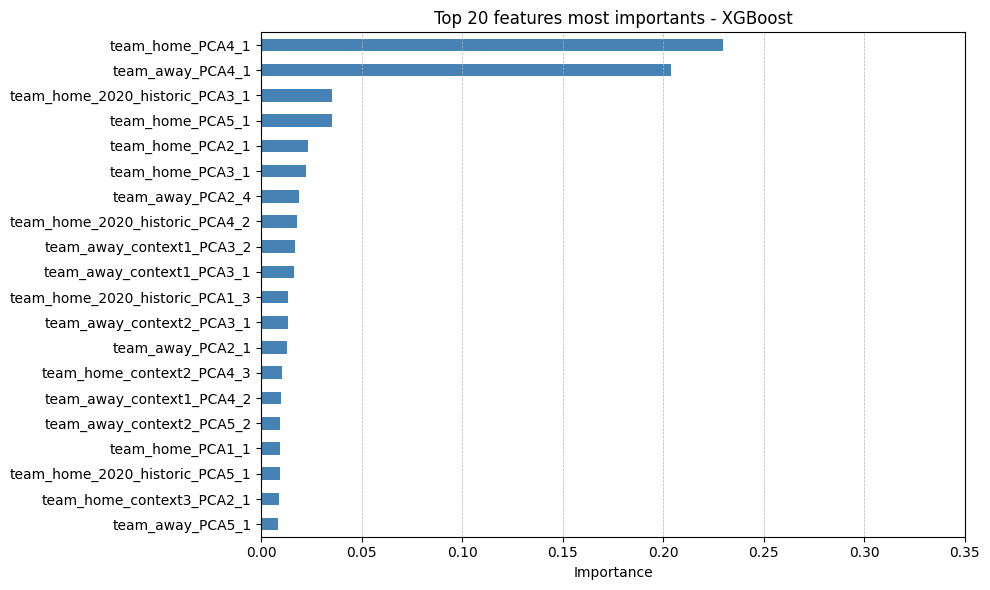

In [50]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

### Three firsts components

In [51]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 3]
df_first_second_third_components = df[filter_cols]
y = df_first_second_third_components['team_home_wins']
X = df_first_second_third_components.drop(['team_home_wins', 'game_id'], axis=1)

In [52]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. team_away_PCA4_1: 0.32127619
2. team_home_PCA4_1: 0.31527008
3. team_home_PCA5_1: 0.03632511
4. team_away_PCA2_1: 0.02539686
5. team_home_PCA3_1: 0.01365958
6. team_home_PCA2_1: 0.01268041
7. team_away_PCA3_1: 0.01146636
8. team_home_PCA1_1: 0.01099584
9. team_away_PCA5_1: 0.00689790
10. team_away_PCA1_1: 0.00602790
11. team_away_context1_PCA3_1: 0.00391727
12. team_away_PCA1_2: 0.00365429
13. team_away_PCA1_3: 0.00363507
14. team_away_context4_PCA1_3: 0.00362852
15. team_away_PCA2_3: 0.00350149
16. team_home_PCA1_2: 0.00328177
17. team_away_PCA4_3: 0.00327908
18. team_away_PCA5_2: 0.00323205
19. team_away_context1_PCA3_2: 0.00310065
20. team_home_context3_PCA2_1: 0.00280141
21. team_away_context2_PCA1_3: 0.00269140
22. team_away_context1_PCA1_3: 0.00264263
23. team_home_2023_historic_PCA3_1: 0.00258176
24. team_away_context2_PCA3_1: 0.00250233
25. team_away_context1_PCA2_3: 0.00248720
26. team_home_2021_historic_PCA3_1: 0.00245646
27. team_away_context2_PCA2_2: 0.00241896
28. team_

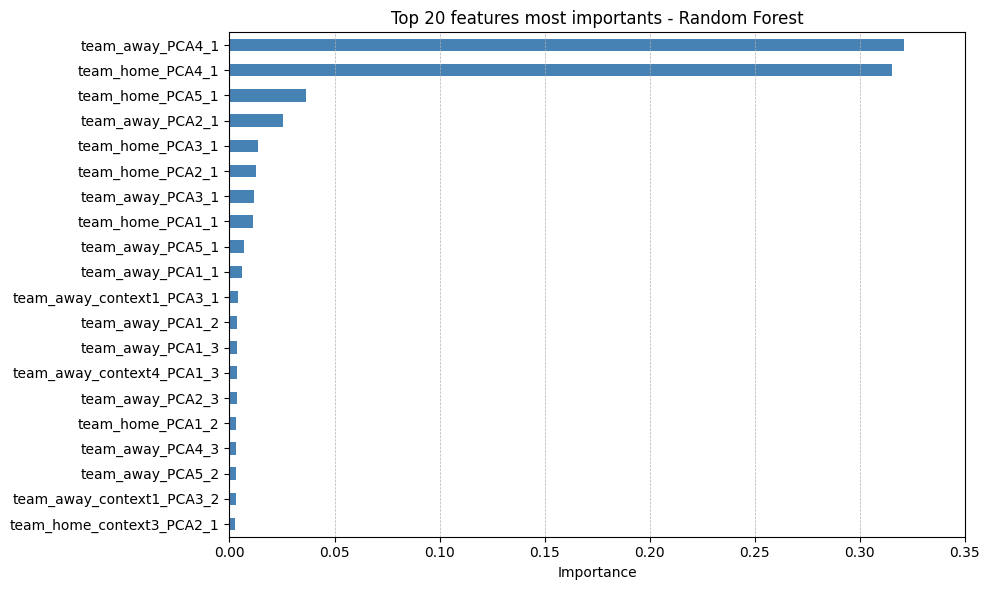

In [53]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [54]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. team_home_PCA4_1: 0.26001501
2. team_away_PCA4_1: 0.20864211
3. team_home_PCA5_1: 0.04836079
4. team_home_2020_historic_PCA3_1: 0.03428730
5. team_home_PCA2_1: 0.02276140
6. team_away_context1_PCA4_2: 0.02121668
7. team_away_context1_PCA3_2: 0.02103239
8. team_away_PCA2_1: 0.01964386
9. team_home_PCA3_1: 0.01772485
10. team_away_PCA3_1: 0.01532337
11. team_home_2020_historic_PCA1_3: 0.01421919
12. team_away_context1_PCA3_1: 0.01223256
13. team_home_2020_historic_PCA4_2: 0.01206743
14. team_home_context3_PCA4_3: 0.01035205
15. team_home_PCA1_1: 0.01008490
16. team_home_context3_PCA2_1: 0.00951583
17. team_home_context2_PCA4_2: 0.00933270
18. team_away_2020_historic_PCA2_3: 0.00822760
19. team_away_PCA5_1: 0.00818064
20. team_away_context2_PCA1_3: 0.00706471
21. team_home_context1_PCA1_1: 0.00673229
22. team_away_context1_PCA1_1: 0.00670977
23. team_away_2020_historic_PCA4_1: 0.00661521
24. team_home_context2_PCA3_1: 0.00660591
25. team_away_context2_PCA2_1: 0.00637821
26. team_home_c

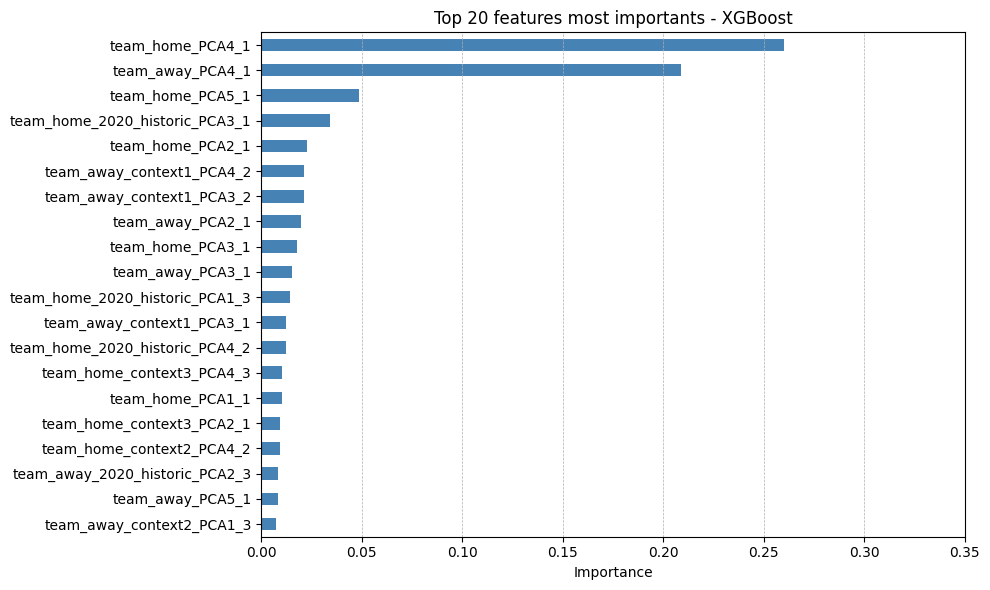

In [55]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

### Two firsts components

In [56]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 2]
df_first_second_components = df[filter_cols]
y = df_first_second_components['team_home_wins']
X = df_first_second_components.drop(['team_home_wins', 'game_id'], axis=1)

In [57]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. team_away_PCA4_1: 0.32311642
2. team_home_PCA4_1: 0.31757452
3. team_home_PCA5_1: 0.03756756
4. team_away_PCA2_1: 0.02754766
5. team_home_PCA3_1: 0.01527426
6. team_home_PCA2_1: 0.01431064
7. team_away_PCA3_1: 0.01369709
8. team_home_PCA1_1: 0.01319294
9. team_away_PCA5_1: 0.00783792
10. team_away_PCA1_1: 0.00712689
11. team_away_context1_PCA3_1: 0.00507451
12. team_away_PCA1_2: 0.00401916
13. team_away_PCA5_2: 0.00401076
14. team_home_PCA1_2: 0.00361967
15. team_away_context1_PCA3_2: 0.00356473
16. team_home_context3_PCA2_1: 0.00335378
17. team_away_context2_PCA3_1: 0.00301725
18. team_away_context2_PCA2_2: 0.00288741
19. team_home_context4_PCA5_1: 0.00282143
20. team_home_context3_PCA4_1: 0.00280947
21. team_home_2024_historic_PCA3_1: 0.00280850
22. team_home_context1_PCA3_2: 0.00279554
23. team_away_PCA2_2: 0.00276631
24. team_home_context3_PCA2_2: 0.00274930
25. team_home_2023_historic_PCA3_1: 0.00249634
26. team_home_context4_PCA5_2: 0.00244637
27. team_away_context1_PCA4_2: 0.

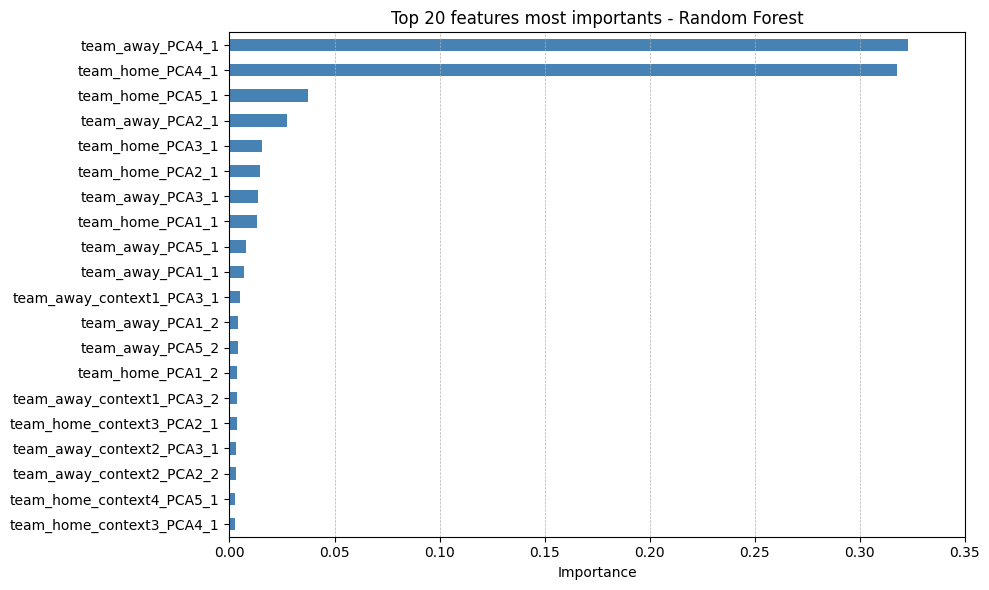

In [58]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [59]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. team_home_PCA4_1: 0.23653999
2. team_away_PCA4_1: 0.18779787
3. team_home_2020_historic_PCA3_1: 0.06164553
4. team_home_PCA5_1: 0.05529211
5. team_home_PCA2_1: 0.02572397
6. team_away_context1_PCA3_2: 0.02198234
7. team_away_context1_PCA3_1: 0.02080502
8. team_away_PCA2_1: 0.02000036
9. team_home_PCA3_1: 0.01781221
10. team_home_PCA1_1: 0.01678542
11. team_away_context1_PCA4_2: 0.01478125
12. team_home_2020_historic_PCA4_2: 0.01415586
13. team_home_context3_PCA2_1: 0.01286865
14. team_away_PCA3_1: 0.01283381
15. team_away_context1_PCA1_1: 0.01157391
16. team_home_context4_PCA1_2: 0.01127697
17. team_away_context2_PCA1_1: 0.01116781
18. team_home_context2_PCA4_2: 0.00997115
19. team_home_context2_PCA5_2: 0.00851042
20. team_home_context1_PCA1_1: 0.00848033
21. team_away_PCA5_1: 0.00819423
22. team_home_context2_PCA3_1: 0.00810707
23. team_away_context3_PCA3_2: 0.00762242
24. team_away_context2_PCA2_1: 0.00734102
25. team_away_context2_PCA3_1: 0.00692645
26. team_home_context2_PCA2_2:

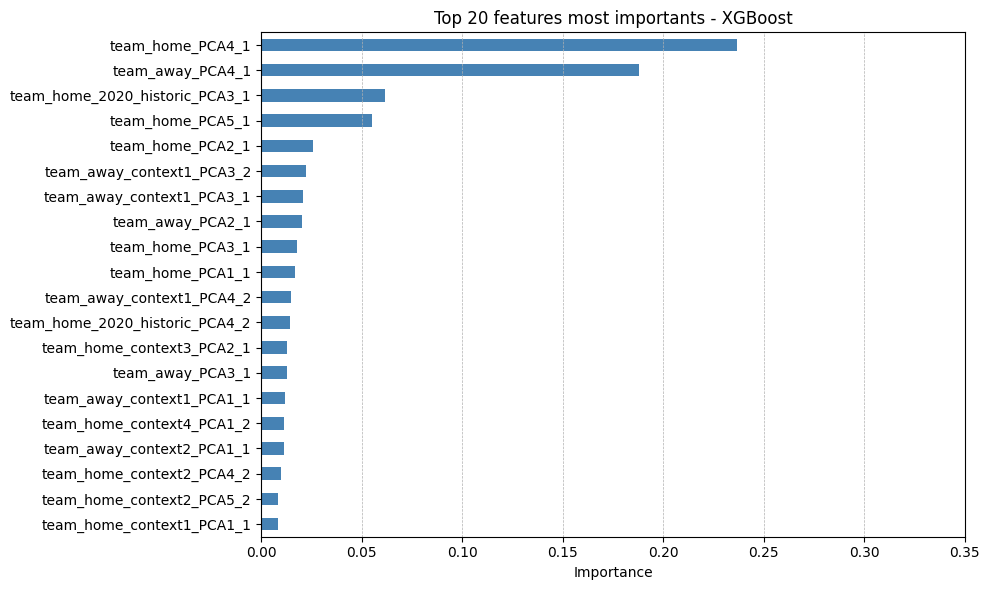

In [60]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

### First component

In [61]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 1]
df_first_components = df[filter_cols]
y = df_first_components['team_home_wins']
X = df_first_components.drop(['team_home_wins', 'game_id'], axis=1)

In [62]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. team_away_PCA4_1: 0.33036449
2. team_home_PCA4_1: 0.32454674
3. team_home_PCA5_1: 0.04062991
4. team_away_PCA2_1: 0.03344605
5. team_home_PCA3_1: 0.01926407
6. team_home_PCA2_1: 0.01915655
7. team_away_PCA3_1: 0.01803827
8. team_home_PCA1_1: 0.01614259
9. team_away_PCA5_1: 0.01117448
10. team_away_PCA1_1: 0.00936860
11. team_away_context1_PCA3_1: 0.00640140
12. team_away_context2_PCA3_1: 0.00530745
13. team_home_context3_PCA4_1: 0.00519033
14. team_home_context3_PCA2_1: 0.00460410
15. team_home_context4_PCA5_1: 0.00402674
16. team_home_context1_PCA2_1: 0.00402011
17. team_home_2023_historic_PCA3_1: 0.00375322
18. team_away_context1_PCA2_1: 0.00363971
19. team_home_2021_historic_PCA3_1: 0.00358971
20. team_away_context4_PCA5_1: 0.00348799
21. team_away_context4_PCA2_1: 0.00322982
22. team_home_2020_historic_PCA3_1: 0.00321671
23. team_home_2022_historic_PCA3_1: 0.00321014
24. team_home_context1_PCA3_1: 0.00319707
25. team_home_2024_historic_PCA3_1: 0.00314808
26. team_away_context1_P

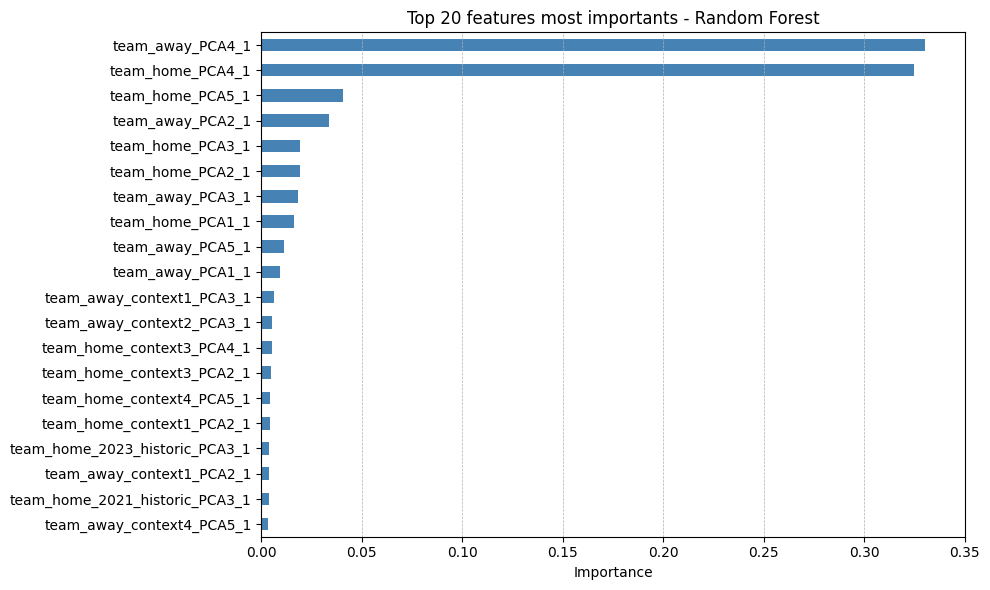

In [63]:
top_n = 20

top_features = importances_rf.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - Random Forest')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

In [64]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. team_home_PCA4_1: 0.28016734
2. team_away_PCA4_1: 0.22321774
3. team_home_PCA5_1: 0.05057912
4. team_home_PCA2_1: 0.04819199
5. team_home_2020_historic_PCA3_1: 0.03869693
6. team_home_PCA3_1: 0.02457583
7. team_away_PCA2_1: 0.02132316
8. team_home_PCA1_1: 0.02001334
9. team_away_PCA5_1: 0.01791397
10. team_away_PCA3_1: 0.01547283
11. team_home_context1_PCA1_1: 0.01377722
12. team_away_2020_historic_PCA3_1: 0.01335952
13. team_home_2020_historic_PCA5_1: 0.01312759
14. team_away_context2_PCA1_1: 0.01204210
15. team_away_context1_PCA3_1: 0.01130083
16. team_home_context4_PCA5_1: 0.01074602
17. team_away_context4_PCA3_1: 0.00980047
18. team_away_context1_PCA1_1: 0.00948659
19. team_away_context1_PCA5_1: 0.00936271
20. team_away_context2_PCA3_1: 0.00930235
21. team_home_2020_historic_PCA4_1: 0.00873898
22. team_home_context2_PCA3_1: 0.00868525
23. team_home_context4_PCA1_1: 0.00848611
24. team_home_context3_PCA2_1: 0.00811525
25. team_away_context1_PCA4_1: 0.00800842
26. team_away_contex

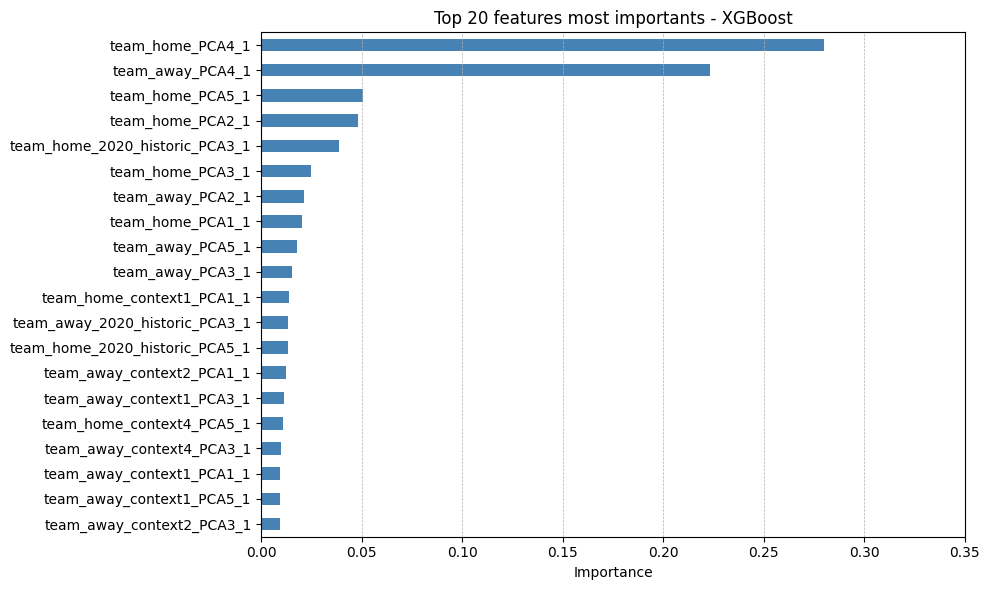

In [65]:
top_features = importances_xgb.head(top_n)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} features most importants - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, 0.35)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()